<a href="https://colab.research.google.com/github/SobowaleAhmed/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

In [3]:
data = pd.read_csv('/content/drive/MyDrive/GoMyCode /Customer-Churn.xls')
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


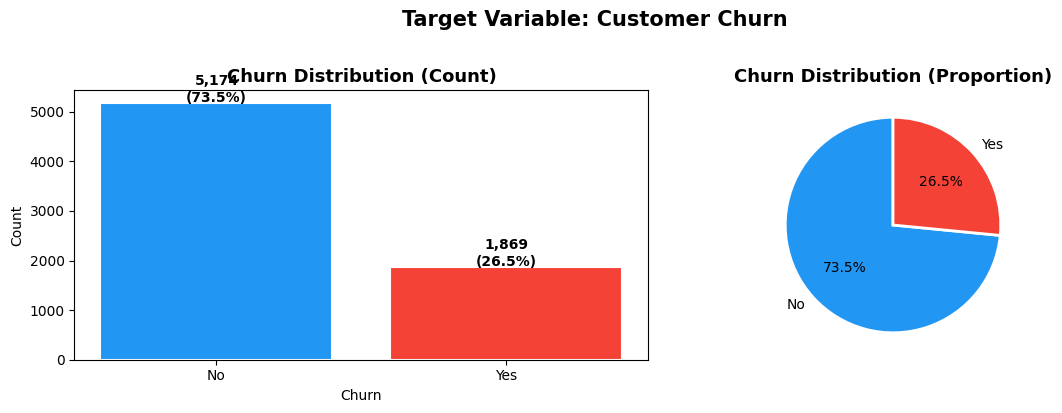

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = data['Churn'].value_counts()
colors = ['#2196F3', '#F44336']

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(data)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

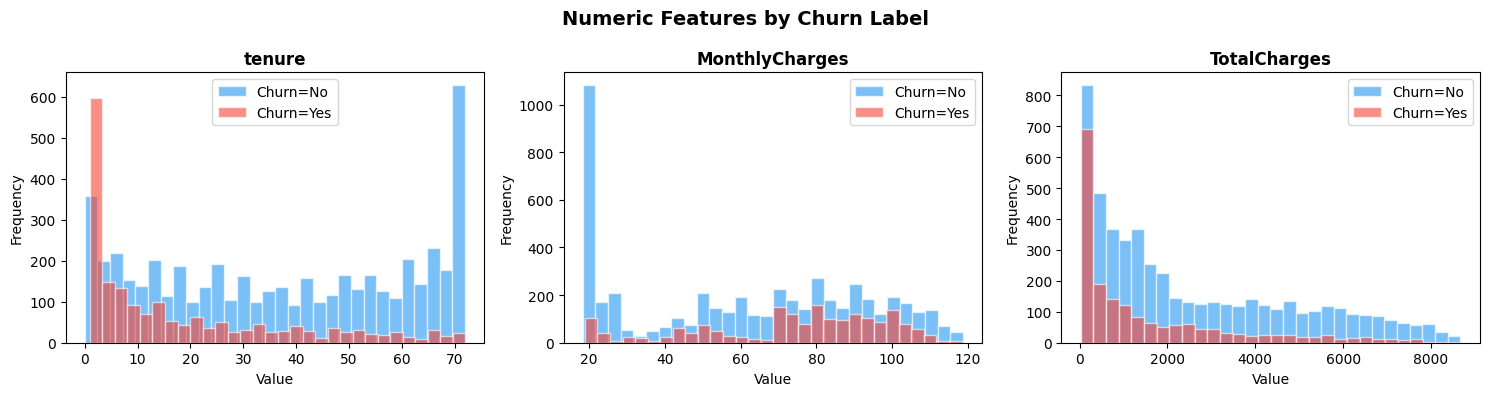

In [9]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    for label, color in zip(['No', 'Yes'], ['#2196F3', '#F44336']):
        subset = data[data['Churn'] == label][col]
        # Convert TotalCharges to numeric (may have spaces)
        subset = pd.to_numeric(subset, errors='coerce').dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Numeric Features by Churn Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Work on a copy
data_copy = data.copy()

# 1. Drop customerID
data.drop(columns=['customerID'], inplace=True)

# 2. Fix TotalCharges
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# 3. Encode binary target
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# 4. Encode all other categorical columns with Label Encoding
cat_cols = data.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

print(f"\n✅ Preprocessing complete")
print(f"Final shape: {data.shape}")
data.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessing complete
Final shape: (7043, 20)


/tmp/ipykernel_194/345857136.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [12]:
# Feature / Target Spli
X = data.drop(columns=['Churn']).values
y = data['Churn'].values

feature_names = data.drop(columns=['Churn']).columns.tolist()

# Train / Test Split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


#  Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [13]:
input_dim = X_train.shape[1]

model = keras.Sequential([
    # ── Input Layer
    layers.Input(shape=(input_dim,), name='Input_Layer'),

    # ── Hidden Layer 1
    layers.Dense(64, activation='relu', name='Hidden_Layer_1'),
    layers.Dropout(0.30, name='Dropout_1'),           # regularization

    # ── Hidden Layer 2 ─
    layers.Dense(32, activation='relu', name='Hidden_Layer_2'),
    layers.Dropout(0.20, name='Dropout_2'),

    # ── Output Layer (sigmoid → probability of churn)
    layers.Dense(1, activation='sigmoid', name='Output_Layer')
], name='Churn_Neural_Network')

model.summary()

Model: "Churn_Neural_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)


In [15]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)

for epoch in range(len(history.history['loss'])):
    t_loss = history.history['loss'][epoch]
    t_acc  = history.history['accuracy'][epoch]
    v_loss = history.history['val_loss'][epoch]
    v_acc  = history.history['val_accuracy'][epoch]


print(f"\n✅ Training complete — {len(history.history['loss'])} epochs ran")

Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 13.

✅ Training complete — 23 epochs ran


In [16]:
print("=" * 45)
print(" TEST SET EVALUATION")
print("=" * 45)

test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test AUC      : {test_auc:.4f}")

# Predictions
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

 TEST SET EVALUATION

  Test Loss     : 0.4237
  Test Accuracy : 79.06%
  Test AUC      : 0.8388
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.62      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

